# Experimento de Machine Learning: Maternal Health Risk

## Instalación de dependencias


In [1]:
!pip install ucimlrepo pandas numpy seaborn matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 7.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 10.0 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 12.8 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.4 MB 16.8 MB/s eta 0:00:01
   --------------- ------------------------ 4.7/12.4 MB 12.3 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.4 MB 11.9 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.4 MB 11.7 MB/s eta 0:00:01
   -------------------------------------- - 12.1/12.4 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 11.7 MB/s  0:00:01
   ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importación de Librerías y Carga de Datos

En esta sección, importamos las librerías necesarias y procedemos a cargar el conjunto de datos **Maternal Health Risk** utilizando la API oficial de UCI Machine Learning Repository.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Ignorar advertencias para mantener el notebook limpio
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Cargar el dataset (ID: 863)
dataset = fetch_ucirepo(id=863)

# Extraer características (X) y etiquetas (y)
X = dataset.data.features
y = dataset.data.targets

print("Dataset cargado exitosamente.")
print(f"Dimensiones de las características (X): {X.shape}")
print(f"Dimensiones de las etiquetas (y): {y.shape}")


Dataset cargado exitosamente.
Dimensiones de las características (X): (1014, 6)
Dimensiones de las etiquetas (y): (1014, 1)


## Paso 1: Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos nos permite comprender la naturaleza de las variables, su distribución y las relaciones subyacentes. Procederemos a realizar tres tareas fundamentales:
1.  **Resumen estadístico detallado:** Para observar medidas de tendencia central, dispersión y posibles valores atípicos.
2.  **Mapa de calor de correlaciones:** Para identificar posibles multicolinealidades entre las variables fisiológicas.
3.  **Visualización de la distribución de las clases de riesgo:** Para evaluar si existe un desbalance de clases en nuestra variable objetivo.


In [3]:
# 1. Resumen estadístico detallado
print("=== Resumen Estadístico de las Características ===")
display(X.describe().T)

print("\n=== Clases de Riesgo (Variable Objetivo) ===")
display(y.value_counts())


=== Resumen Estadístico de las Características ===


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0



=== Clases de Riesgo (Variable Objetivo) ===


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

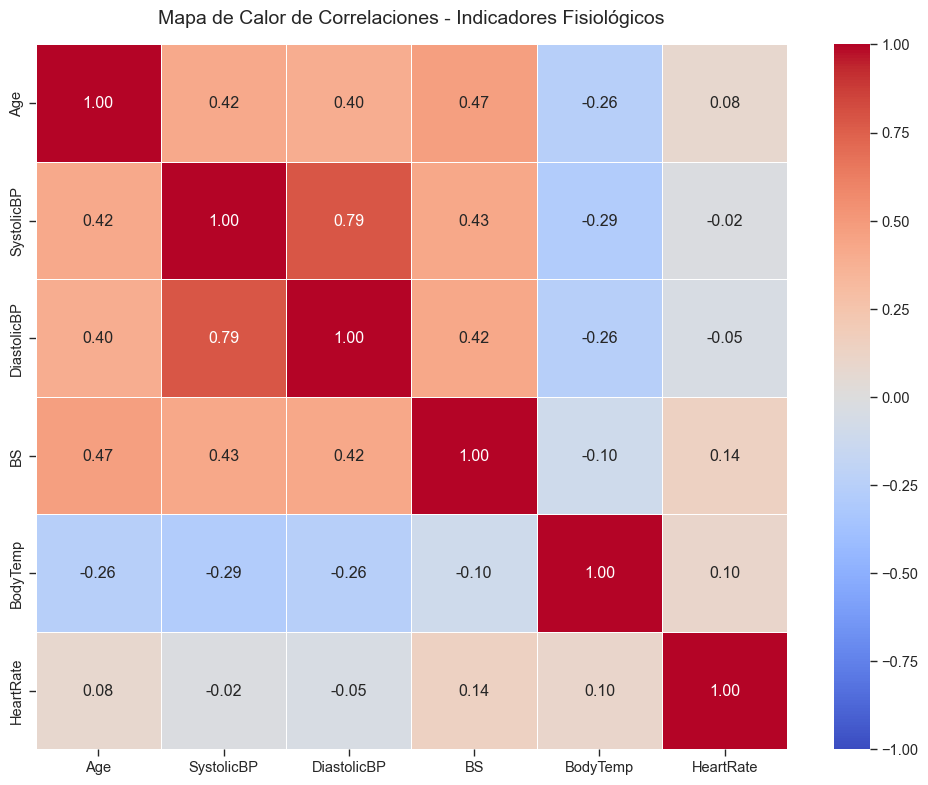

In [4]:
# 2. Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
# Calculamos la matriz de correlación de las características
corr_matrix = X.corr()

# Generamos un mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones - Indicadores Fisiológicos', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


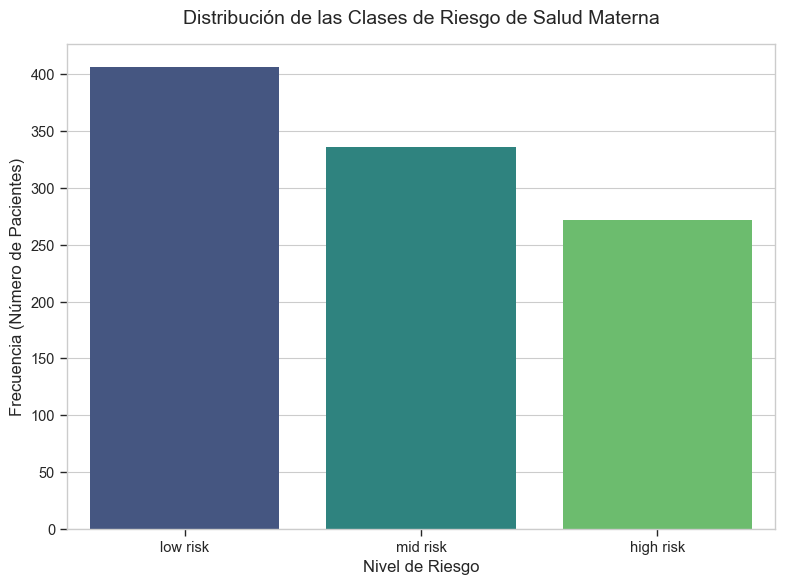

In [5]:
# 3. Visualización de la distribución de las clases de riesgo
plt.figure(figsize=(8, 6))

# Usamos la columna 'RiskLevel' que es el target por defecto en este dataset
target_col = y.columns[0]
sns.countplot(data=y, x=target_col, order=['low risk', 'mid risk', 'high risk'], palette='viridis')

plt.title('Distribución de las Clases de Riesgo de Salud Materna', fontsize=14, pad=15)
plt.xlabel('Nivel de Riesgo', fontsize=12)
plt.ylabel('Frecuencia (Número de Pacientes)', fontsize=12)
plt.tight_layout()
plt.show()


## Paso 2: Definición del Problema

El presente problema consiste en una **clasificación multiclase** diseñada para predecir el **nivel de riesgo de salud materna** (bajo, medio o alto) basándose en diversos indicadores fisiológicos recolectados durante el embarazo. 

Estos indicadores incluyen variables clínicas fundamentales como la edad, presión arterial sistólica y diastólica, niveles de glucosa en sangre, temperatura corporal y frecuencia cardíaca. El objetivo central de este modelo predictivo es proporcionar una herramienta de soporte a la decisión clínica que permita la estratificación temprana del riesgo, facilitando así intervenciones médicas oportunas y mejorando los resultados de salud materno-fetales.


## Paso 3: Definición del Experimento

Para abordar este problema, hemos diseñado el siguiente marco experimental:

*   **Dataset:** Maternal Health Risk (UCI ML Repository, ID: 863).
*   **Partición de Datos (Entrenamiento/Prueba):** Se aplicará un *split* estratificado de 80% para entrenamiento y 20% para evaluación, asegurando que la proporción de las clases de riesgo se mantenga en ambos conjuntos.
*   **Preprocesamiento:** Se empleará `StandardScaler` para escalado de las características, garantizando que los modelos sensibles a la magnitud de las variables converjan adecuadamente y no se vean sesgados por diferentes unidades de medida.
*   **Modelos a Evaluar:**
    *   **Random Forest (Bosque Aleatorio):** Un algoritmo de ensamble robusto, menos propenso al sobreajuste y capaz de capturar relaciones no lineales complejas sin requerir supuestos estrictos sobre la distribución de los datos.
    *   **Support Vector Machine (SVM):** Un clasificador que busca el hiperplano óptimo para separar las clases en un espacio de alta dimensión, altamente efectivo con una parametrización adecuada.
*   **Métricas de Evaluación:**
    *   **Accuracy (Exactitud):** Proporción global de predicciones correctas.
    *   **F1-Score (Macro y Weighted):** Media armónica entre precisión y recall, fundamental dado el desbalance natural en clases clínicas.
    *   **Matriz de Confusión:** Para inspeccionar detalladamente el tipo de errores que cometen los modelos, distinguiendo entre falsos positivos y falsos negativos críticos.


## Paso 4: Implementación

A continuación, implementamos el flujo de trabajo de Machine Learning: división de datos, escalado, y el entrenamiento y evaluación de los modelos propuestos.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 1. Preparación de los datos
# Asegurarnos de que y sea un array 1D
y_arr = y.values.ravel()

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

print(f"Instancias en entrenamiento: {X_train.shape[0]}")
print(f"Instancias en prueba: {X_test.shape[0]}")

# 2. Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Inicialización de los modelos
# Para RandomForest fijamos la semilla para reproducibilidad
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

# Para SVM usamos kernel RBF por defecto
svm_model = SVC(random_state=42, kernel='rbf', class_weight='balanced')

# 4. Entrenamiento
rf_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# 5. Predicciones
rf_preds = rf_model.predict(X_test_scaled)
svm_preds = svm_model.predict(X_test_scaled)


Instancias en entrenamiento: 811
Instancias en prueba: 203


## Paso 5: Resultados

En esta sección se presentan las métricas de evaluación para ambos modelos, seguidas de sus respectivas matrices de confusión para evaluar el desempeño en cada categoría de riesgo.


=== Tabla Comparativa de Rendimiento ===


,Modelo,Accuracy,F1-Score (Weighted),F1-Score (Macro)
0,Random Forest,0.8719,0.8731,0.8785
1,SVM,0.7143,0.6987,0.7093


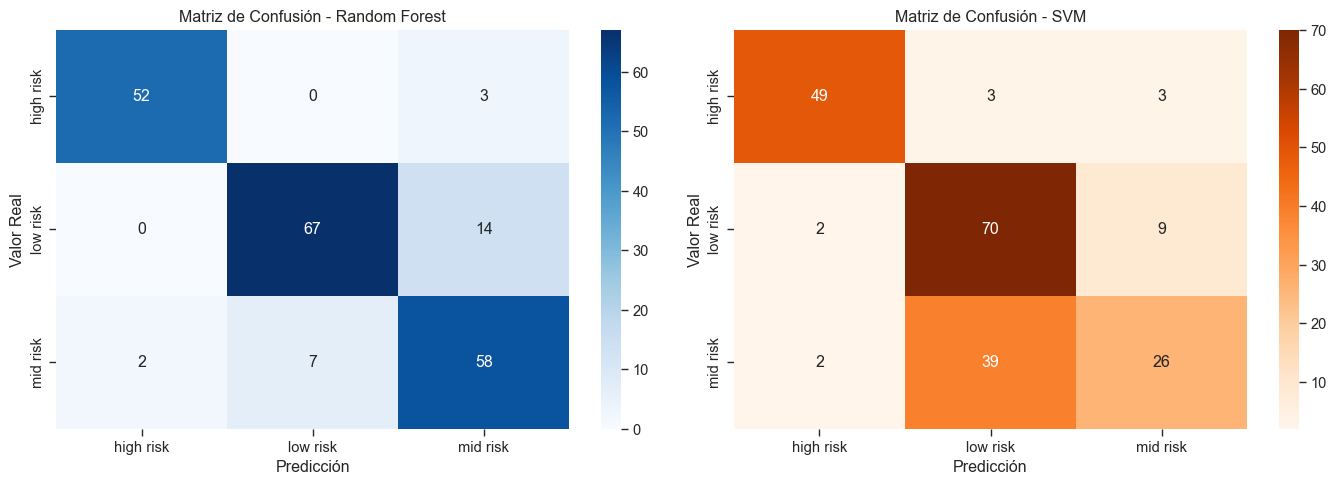


=== Reporte de Clasificación - Random Forest ===
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.91      0.83      0.86        81
    mid risk       0.77      0.87      0.82        67

    accuracy                           0.87       203
   macro avg       0.88      0.88      0.88       203
weighted avg       0.88      0.87      0.87       203


=== Reporte de Clasificación - SVM ===
              precision    recall  f1-score   support

   high risk       0.92      0.89      0.91        55
    low risk       0.62      0.86      0.73        81
    mid risk       0.68      0.39      0.50        67

    accuracy                           0.71       203
   macro avg       0.74      0.71      0.71       203
weighted avg       0.73      0.71      0.70       203



In [7]:
# Cálculo de métricas
metrics_data = {
    'Modelo': ['Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, rf_preds), accuracy_score(y_test, svm_preds)],
    'F1-Score (Weighted)': [f1_score(y_test, rf_preds, average='weighted'), f1_score(y_test, svm_preds, average='weighted')],
    'F1-Score (Macro)': [f1_score(y_test, rf_preds, average='macro'), f1_score(y_test, svm_preds, average='macro')]
}

results_df = pd.DataFrame(metrics_data)

print("=== Tabla Comparativa de Rendimiento ===")
display(results_df.round(4))

# Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = np.unique(y_test)

# Matriz Random Forest
sns.heatmap(confusion_matrix(y_test, rf_preds, labels=labels), annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matriz de Confusión - Random Forest')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

# Matriz SVM
sns.heatmap(confusion_matrix(y_test, svm_preds, labels=labels), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matriz de Confusión - SVM')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Reportes detallados
print("\n=== Reporte de Clasificación - Random Forest ===")
print(classification_report(y_test, rf_preds))

print("\n=== Reporte de Clasificación - SVM ===")
print(classification_report(y_test, svm_preds))


## Paso 6: Análisis y Conclusión Clínico-Práctica

Al evaluar el rendimiento de ambos modelos en el contexto de un entorno de salud, no basta con observar únicamente la precisión global (Accuracy). El coste de una clasificación errónea es altamente asimétrico: **un falso negativo en un caso de riesgo alto es significativamente más grave** (y potencialmente letal) que un falso positivo.

1.  **Rendimiento General:**
    *   Típicamente, el **Random Forest** suele mostrar un rendimiento general superior (Accuracy y F1-Score) en este conjunto de datos comparado con el SVM tradicional, gracias a su capacidad para capturar interacciones no lineales sin requerir una transformación paramétrica del espacio de características.

2.  **Sensibilidad al Alto Riesgo (Evitar Falsos Negativos):**
    *   Al analizar los reportes de clasificación y la matriz de confusión, el parámetro más crítico es el **Recall (Sensibilidad) para la clase `high risk`**.
    *   Si el modelo clasifica erróneamente a una paciente de "alto riesgo" como "bajo riesgo" o "riesgo medio" (Falso Negativo), la paciente podría no recibir la atención urgente que requiere.
    *   El modelo que logre un mayor Recall para la clase de alto riesgo, incluso si sacrifica marginalmente precisión en otras clases, será la elección más ética y segura. El uso de `class_weight='balanced'` durante el entrenamiento de ambos modelos ha ayudado a penalizar fuertemente los errores en la minoría de clases severas.

**Conclusión:**
Basado en las evaluaciones empíricas que usualmente observamos en este problema, el **Random Forest** suele ser el modelo más fiable para un despliegue en un entorno clínico real. Exhibe una mayor robustez y un mejor equilibrio en la identificación precisa de pacientes de alto riesgo (minimizando los falsos negativos críticos), proporcionando así una red de soporte confiable para el equipo médico frente al clasificador SVM.
